# Experiment 3: GRU with Log Returns

In this experiment, a GRU model will be trained on the same
log-return data used by the LSTM model.

The purpose is to compare LSTM and GRU under approximately
the same experimental conditions.

## Prediction Task

Input:

`previous 20 daily log returns`

Target:

`next daily log return`

The predicted log return will be converted back into a next-day
stock price using the most recently known price.

## Comparison Goal

The final comparison will include:

- Naive baseline
- Log-Return LSTM
- Log-Return GRU


In [1]:
from pathlib import Path
import copy
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset


## Setup

In [2]:
def get_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device("mps")

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


device = get_device()

torch.manual_seed(42)
np.random.seed(42)

print("Device:", device)


Device: mps


In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_directory = project_root / "data"
models_directory = project_root / "models"
results_directory = project_root / "results"

models_directory.mkdir(exist_ok=True)
results_directory.mkdir(exist_ok=True)


## Prepared Log-Return Data

In [4]:
prepared_data = np.load(
    data_directory / "aapl_returns_prepared.npz"
)

X_train = prepared_data["X_train"]
y_train = prepared_data["y_train"]

X_validation = prepared_data["X_validation"]
y_validation = prepared_data["y_validation"]

X_test = prepared_data["X_test"]
y_test = prepared_data["y_test"]

test_target_indices = prepared_data[
    "test_target_indices"
]


In [5]:
print("Train:", X_train.shape, y_train.shape)
print(
    "Validation:",
    X_validation.shape,
    y_validation.shape,
)
print("Test:", X_test.shape, y_test.shape)


Train: (1915, 20, 1) (1915, 1)
Validation: (415, 20, 1) (415, 1)
Test: (415, 20, 1) (415, 1)


In [6]:
return_scaler = joblib.load(
    data_directory / "aapl_return_scaler.joblib"
)


## Data Loaders

In [7]:
X_train_tensor = torch.from_numpy(X_train)
y_train_tensor = torch.from_numpy(y_train)

X_validation_tensor = torch.from_numpy(
    X_validation
)
y_validation_tensor = torch.from_numpy(
    y_validation
)

X_test_tensor = torch.from_numpy(X_test)

BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor,
)

validation_dataset = TensorDataset(
    X_validation_tensor,
    y_validation_tensor,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


## GRU Model

The GRU uses a single hidden state with reset and update gates. It keeps the same input and output structure as the LSTM while generally requiring fewer parameters.

An input batch with shape `[batch, 20, 1]` produces GRU outputs with shape `[batch, 20, 32]`. The last time step is passed through a linear layer to produce `[batch, 1]`.


In [8]:
class GRUModel(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1,
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> torch.Tensor:
        gru_output, _ = self.gru(x)

        last_time_step = (
            gru_output[:, -1, :]
        )

        prediction = self.output_layer(
            last_time_step
        )

        return prediction


In [9]:
INPUT_SIZE = 1
HIDDEN_SIZE = 32
NUM_LAYERS = 2
DROPOUT = 0.2

LEARNING_RATE = 0.001
NUMBER_OF_EPOCHS = 100
PATIENCE = 15

model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

print(model)


GRUModel(
  (gru): GRU(1, 32, num_layers=2, batch_first=True, dropout=0.2)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
number_of_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Total parameters:",
    number_of_parameters,
)

print(
    "Trainable parameters:",
    trainable_parameters,
)


Total parameters: 9729
Trainable parameters: 9729


In [11]:
batch_X, batch_y = next(
    iter(train_loader)
)

batch_X = batch_X.to(device)

with torch.no_grad():
    sample_predictions = model(
        batch_X
    )

print("Input:", batch_X.shape)
print(
    "Output:",
    sample_predictions.shape,
)


Input: torch.Size([32, 20, 1])
Output: torch.Size([32, 1])


In [12]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)


## Training

In [13]:
training_losses = []
validation_losses = []

best_validation_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

training_start_time = time.perf_counter()

for epoch in range(NUMBER_OF_EPOCHS):
    model.train()

    total_training_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_X)

        loss = loss_function(
            predictions,
            batch_y,
        )

        loss.backward()
        optimizer.step()

        total_training_loss += (
            loss.item()
            * batch_X.size(0)
        )

    average_training_loss = (
        total_training_loss
        / len(train_dataset)
    )

    training_losses.append(
        average_training_loss
    )

    model.eval()

    total_validation_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in validation_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_X)

            validation_loss = loss_function(
                predictions,
                batch_y,
            )

            total_validation_loss += (
                validation_loss.item()
                * batch_X.size(0)
            )

    average_validation_loss = (
        total_validation_loss
        / len(validation_dataset)
    )

    validation_losses.append(
        average_validation_loss
    )

    if average_validation_loss < best_validation_loss:
        best_validation_loss = average_validation_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train: {average_training_loss:.6f} | "
            f"Validation: {average_validation_loss:.6f}"
        )

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch + 1}"
        )
        break


Epoch  10 | Train: 0.986423 | Validation: 0.781817
Epoch  20 | Train: 0.955671 | Validation: 0.777679
Epoch  30 | Train: 0.926151 | Validation: 0.782845
Early stopping at epoch 30


In [14]:
training_time = (
    time.perf_counter()
    - training_start_time
)

model.load_state_dict(
    best_model_state
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"Best validation loss: "
    f"{best_validation_loss:.6f}"
)


Training time: 30.82 seconds
Best validation loss: 0.774469


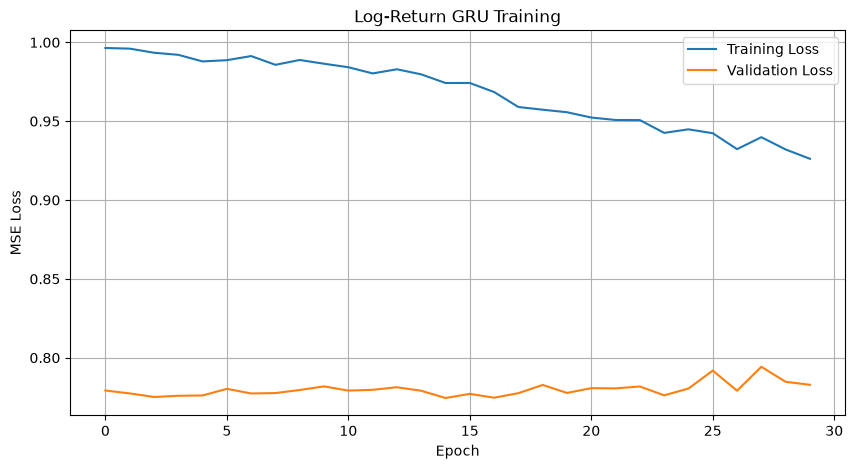

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    training_losses,
    label="Training Loss",
)

plt.plot(
    validation_losses,
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Log-Return GRU Training")
plt.legend()
plt.grid(True)
plt.show()


## Evaluation

In [16]:
model.eval()

with torch.no_grad():
    predicted_returns_scaled = model(
        X_test_tensor.to(device)
    )

predicted_returns_scaled = (
    predicted_returns_scaled
    .cpu()
    .numpy()
)

predicted_returns = (
    return_scaler.inverse_transform(
        predicted_returns_scaled
    )
    .ravel()
)

actual_returns = (
    return_scaler.inverse_transform(
        y_test
    )
    .ravel()
)


In [17]:
return_mse = mean_squared_error(
    actual_returns,
    predicted_returns,
)

return_rmse = np.sqrt(return_mse)

print(
    f"GRU Return RMSE: "
    f"{return_rmse:.6f}"
)


GRU Return RMSE: 0.017959


In [18]:
price_df = pd.read_csv(
    data_directory / "aapl_clean.csv",
    parse_dates=["date"],
)

return_df = price_df[
    ["date", "price"]
].copy()

return_df["previous_price"] = (
    return_df["price"].shift(1)
)

return_df["log_return"] = np.log(
    return_df["price"]
    / return_df["previous_price"]
)

return_df = (
    return_df
    .dropna()
    .reset_index(drop=True)
)

test_rows = return_df.iloc[
    test_target_indices
].copy()


In [19]:
previous_prices = (
    test_rows["previous_price"]
    .to_numpy()
)

actual_prices = (
    test_rows["price"]
    .to_numpy()
)

gru_predictions = (
    previous_prices
    * np.exp(predicted_returns)
)

baseline_predictions = (
    previous_prices.copy()
)


In [20]:
gru_mae = mean_absolute_error(
    actual_prices,
    gru_predictions,
)

gru_mse = mean_squared_error(
    actual_prices,
    gru_predictions,
)

gru_rmse = np.sqrt(gru_mse)

baseline_mae = mean_absolute_error(
    actual_prices,
    baseline_predictions,
)

baseline_mse = mean_squared_error(
    actual_prices,
    baseline_predictions,
)

baseline_rmse = np.sqrt(baseline_mse)


In [21]:
actual_direction = np.sign(
    actual_returns
)

predicted_direction = np.sign(
    predicted_returns
)

direction_accuracy = (
    np.mean(
        actual_direction
        == predicted_direction
    )
    * 100
)

print(
    f"Direction Accuracy: "
    f"{direction_accuracy:.2f}%"
)


Direction Accuracy: 52.77%


In [22]:
comparison_df = pd.DataFrame({
    "model": [
        "Naive Baseline",
        "Log-Return GRU",
    ],
    "mae": [
        baseline_mae,
        gru_mae,
    ],
    "mse": [
        baseline_mse,
        gru_mse,
    ],
    "rmse": [
        baseline_rmse,
        gru_rmse,
    ],
})

comparison_df.round(4)


,model,mae,mse,rmse
0,Naive Baseline,2.5887,14.7321,3.8382
1,Log-Return GRU,2.5919,14.7714,3.8434


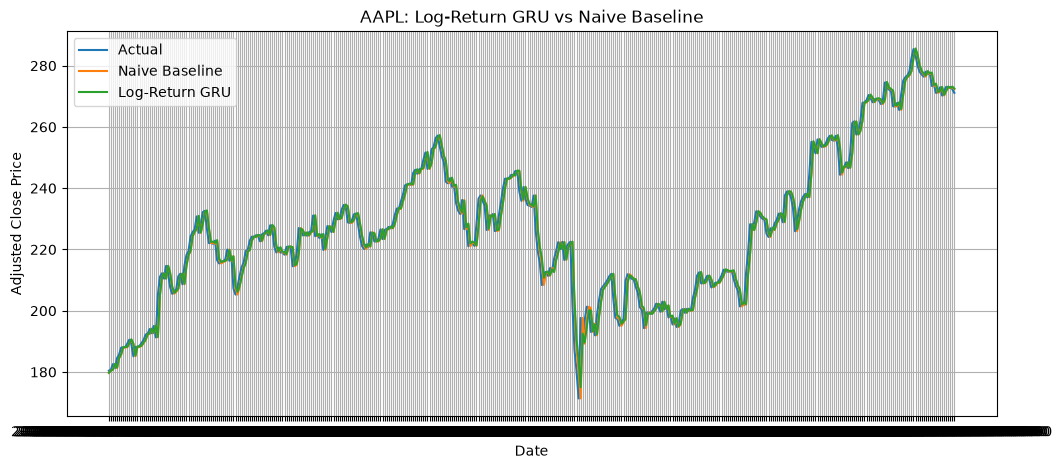

In [23]:
test_dates = (
    test_rows["date"]
    .to_numpy()
)

plt.figure(figsize=(12, 5))

plt.plot(
    test_dates,
    actual_prices,
    label="Actual",
)

plt.plot(
    test_dates,
    baseline_predictions,
    label="Naive Baseline",
)

plt.plot(
    test_dates,
    gru_predictions,
    label="Log-Return GRU",
)

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.title(
    "AAPL: Log-Return GRU "
    "vs Naive Baseline"
)

plt.legend()
plt.grid(True)

comparison_plot_path = (
    results_directory
    / "gru_log_return_comparison.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


## Save Results

In [24]:
results_df = pd.DataFrame({
    "date": test_dates,
    "previous_price": previous_prices,
    "actual_price": actual_prices,
    "actual_return": actual_returns,
    "predicted_return": predicted_returns,
    "baseline_price": baseline_predictions,
    "gru_price": gru_predictions,
})

results_df["absolute_error"] = (
    results_df["actual_price"]
    - results_df["gru_price"]
).abs()

results_df.head()


,date,previous_price,actual_price,actual_return,predicted_return,baseline_price,gru_price,absolute_error
0,2024-05-07 00:00:00-04:00,179.750443,180.432968,0.003790,-0.000164,179.750443,179.720883,0.712085
1,2024-05-08 00:00:00-04:00,180.432968,180.769318,0.001862,-0.000030,180.432968,180.427569,0.341748
2,2024-05-09 00:00:00-04:00,180.769318,182.579605,0.009965,0.000186,180.769318,180.802999,1.776606
3,2024-05-10 00:00:00-04:00,182.579605,181.321564,-0.006914,0.000329,182.579605,182.639612,1.318048
4,2024-05-13 00:00:00-04:00,181.321564,184.521072,0.017492,0.000412,181.321564,181.396331,3.124742


In [25]:
results_df.sort_values(
    by="absolute_error",
    ascending=False,
).head(10).round(4)


,date,previous_price,actual_price,actual_return,predicted_return,baseline_price,gru_price,absolute_error
231,2025-04-09 00:00:00-04:00,171.3660,197.6344,0.1426,0.0211,171.3660,175.0260,22.6084
227,2025-04-03 00:00:00-04:00,222.5213,201.9478,-0.0970,0.0001,222.5213,222.5503,20.6025
228,2025-04-04 00:00:00-04:00,201.9478,187.2284,-0.0757,0.0067,201.9478,203.3124,16.0840
24,2024-06-11 00:00:00-04:00,191.2965,205.1940,0.0701,0.0008,191.2965,191.4530,13.7410
230,2025-04-08 00:00:00-04:00,180.3507,171.3660,-0.0511,0.0196,180.3507,183.9284,12.5624
253,2025-05-12 00:00:00-04:00,197.3163,209.7761,0.0612,-0.0000,197.3163,197.3129,12.4632
209,2025-03-10 00:00:00-04:00,237.6085,226.0894,-0.0497,-0.0001,237.6085,237.5961,11.5067
61,2024-08-05 00:00:00-04:00,217.7840,207.2940,-0.0494,0.0001,217.7840,217.8000,10.5060
344,2025-09-22 00:00:00-04:00,244.5965,255.1375,0.0422,0.0003,244.5965,244.6667,10.4708
229,2025-04-07 00:00:00-04:00,187.2284,180.3507,-0.0374,0.0180,187.2284,190.6365,10.2858


In [26]:
model_path = (
    models_directory
    / "aapl_gru_log_return.pth"
)

torch.save(
    model.state_dict(),
    model_path,
)

print("Saved:", model_path)


Saved: /Users/omurravli/Desktop/pythorch_stock_predict/models/aapl_gru_log_return.pth


In [27]:
results_path = (
    results_directory
    / "gru_log_return_predictions.csv"
)

results_df.to_csv(
    results_path,
    index=False,
)


In [28]:
metrics_df = pd.DataFrame({
    "model": [
        "Log-Return GRU"
    ],
    "mae": [
        gru_mae
    ],
    "mse": [
        gru_mse
    ],
    "rmse": [
        gru_rmse
    ],
    "return_rmse": [
        return_rmse
    ],
    "direction_accuracy_pct": [
        direction_accuracy
    ],
    "training_time_seconds": [
        training_time
    ],
    "parameters": [
        trainable_parameters
    ],
})

metrics_df


,model,mae,mse,rmse,return_rmse,direction_accuracy_pct,training_time_seconds,parameters
0,Log-Return GRU,2.591856,14.77136,3.843353,0.017959,52.771084,30.818724,9729


In [29]:
metrics_path = (
    results_directory
    / "gru_log_return_metrics.csv"
)

metrics_df.to_csv(
    metrics_path,
    index=False,
)

print("Saved:", results_path)
print("Saved:", metrics_path)
print("Saved:", comparison_plot_path)


Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/gru_log_return_predictions.csv
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/gru_log_return_metrics.csv
Saved: /Users/omurravli/Desktop/pythorch_stock_predict/results/gru_log_return_comparison.png


## Conclusion

In this experiment, a GRU model was trained using the same
log-return dataset, chronological split, lookback window and
hyperparameters used for the Log-Return LSTM experiment.

The purpose of keeping the experimental setup consistent was to
make the LSTM and GRU comparison as fair as possible.

Unlike the original direct price-level model, the GRU predicts the
next day's log return and reconstructs the next stock price using
the most recently observed price.

The GRU results will be compared with:

- the naive persistence baseline,
- the Log-Return LSTM,
- and the original direct price-level LSTM experiment.

The final evaluation will consider not only MAE and RMSE, but also
return prediction error, directional accuracy, training time and
model parameter count.
